# Notebook 4: Model Training
## AI-Powered Job Market Intelligence — Sri Lanka

### What we do here:
- TF-IDF  → finds most important skills in job postings
- K-Means → groups similar jobs into clusters
- Topic Modeling (LDA) → finds hidden themes in job descriptions

Input  → data/processed/jobs_with_skills.csv
Output → data/processed/model_results.csv

In [1]:
# ── IMPORTS ──────────────────────────────────

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF model
from sklearn.cluster import KMeans                            # K-Means clustering
from sklearn.decomposition import LatentDirichletAllocation   # Topic modeling (LDA)
from sklearn.preprocessing import normalize                   # Normalize data

# For visualizing clusters
from sklearn.decomposition import PCA                         # Reduces dimensions for visualization

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# ── SET PATHS ────────────────────────────────

BASE_PATH            = 'D:/Sinali/projects/job_market_intelligence_platform'
RAW_DATA_PATH        = f'{BASE_PATH}/data/raw'
PROCESSED_DATA_PATH  = f'{BASE_PATH}/data/processed'
OUTPUT_PATH          = f'{BASE_PATH}/outputs'

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── LOAD DATA ────────────────────────────────

print("📂 Loading data...")

df = pd.read_csv(f'{PROCESSED_DATA_PATH}/jobs_with_skills.csv')

# Fill any missing values
df['description_clean'] = df['description_clean'].fillna('')
df['skills_clean']      = df['skills_clean'].fillna('')
df['all_skills_str']    = df['all_skills_str'].fillna('')

print(f"✅ Data loaded!")
print(f"📊 Rows    : {len(df)}")
print(f"📊 Columns : {len(df.columns)}")
print(f"\n📋 Columns:")
for col in df.columns.tolist():
    print(f"   → {col}")

📂 Loading data...
✅ Data loaded!
📊 Rows    : 4301
📊 Columns : 20

📋 Columns:
   → title
   → description
   → skills
   → salary
   → experience
   → qualification
   → location
   → country
   → work_type
   → company
   → date_posted
   → role
   → description_clean
   → skills_clean
   → title_clean
   → extracted_skills
   → desc_skills
   → all_skills
   → skill_count
   → all_skills_str


In [3]:
# ── TF-IDF MODEL ─────────────────────────────

print("⚙️ Training TF-IDF model...")

# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=100,   # Keep top 100 most important words
    min_df=5,           # Word must appear in at least 5 jobs
    max_df=0.85,        # Ignore words appearing in more than 85% of jobs
    ngram_range=(1, 2)  # Consider single words AND two-word phrases
)

# Fit and transform the descriptions
# This converts text into a matrix of numbers
tfidf_matrix = tfidf.fit_transform(df['description_clean'])

print(f"✅ TF-IDF complete!")
print(f"📊 Matrix shape     : {tfidf_matrix.shape}")
print(f"   Rows = jobs, Columns = unique words/phrases")
print(f"\n📋 Top 20 most important words found by TF-IDF:")
print("=" * 40)

# Get feature names and their importance scores
feature_names = tfidf.get_feature_names_out()
importance     = np.array(tfidf_matrix.sum(axis=0)).flatten()
top_indices    = importance.argsort()[::-1][:20]

for i, idx in enumerate(top_indices):
    print(f"   {i+1:>2}. {feature_names[idx]:<30} score: {importance[idx]:.2f}")

⚙️ Training TF-IDF model...
✅ TF-IDF complete!
📊 Matrix shape     : (4301, 100)
   Rows = jobs, Columns = unique words/phrases

📋 Top 20 most important words found by TF-IDF:
    1. user                           score: 348.44
    2. data                           score: 335.19
    3. design                         score: 324.45
    4. system                         score: 279.72
    5. network                        score: 228.77
    6. create                         score: 212.92
    7. ensure                         score: 199.17
    8. security                       score: 196.46
    9. designer                       score: 192.46
   10. engineer                       score: 188.83
   11. software                       score: 182.32
   12. performance                    score: 177.65
   13. application                    score: 173.22
   14. quality                        score: 165.23
   15. interface                      score: 163.43
   16. business                       score: 

In [4]:
# ── K-MEANS CLUSTERING ───────────────────────
# K-Means groups similar jobs into clusters
# We use 6 clusters = 6 types of IT jobs

print("⚙️ Training K-Means model...")

# Number of clusters
# We choose 6 because we have roughly 6 types of IT jobs
K = 6

kmeans = KMeans(
    n_clusters=K,
    random_state=42,    # For reproducibility
    n_init=10           # Run 10 times, pick best result
)

# Fit model on TF-IDF matrix
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f"✅ K-Means complete!")
print(f"📊 Number of clusters : {K}")
print(f"\n📋 Jobs per cluster:")
print("=" * 40)

cluster_counts = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"   Cluster {cluster} : {count} jobs")

print(f"\n📋 Sample jobs per cluster:")
print("=" * 40)
for i in range(K):
    cluster_jobs = df[df['cluster'] == i]['title'].value_counts().head(3)
    print(f"\nCluster {i}:")
    for title, count in cluster_jobs.items():
        print(f"   → {title} ({count} jobs)")

⚙️ Training K-Means model...
✅ K-Means complete!
📊 Number of clusters : 6

📋 Jobs per cluster:
   Cluster 0 : 820 jobs
   Cluster 1 : 403 jobs
   Cluster 2 : 1815 jobs
   Cluster 3 : 557 jobs
   Cluster 4 : 480 jobs
   Cluster 5 : 226 jobs

📋 Sample jobs per cluster:

Cluster 0:
   → UX/UI Designer (288 jobs)
   → Graphic Designer (102 jobs)
   → UI Developer (96 jobs)

Cluster 1:
   → Software Tester (79 jobs)
   → Java Developer (67 jobs)
   → Software Engineer (61 jobs)

Cluster 2:
   → Digital Marketing Specialist (181 jobs)
   → Architect (95 jobs)
   → Landscape Architect (90 jobs)

Cluster 3:
   → Financial Analyst (84 jobs)
   → Marketing Analyst (78 jobs)
   → Data Analyst (71 jobs)

Cluster 4:
   → Network Engineer (163 jobs)
   → Network Administrator (106 jobs)
   → Network Security Specialist (73 jobs)

Cluster 5:
   → Systems Administrator (58 jobs)
   → Database Developer (48 jobs)
   → Database Administrator (39 jobs)


✅ Clusters named!

📋 Jobs per cluster:
   Design & UI/UX                 : 820 jobs (19.1%)
   Software Development           : 403 jobs (9.4%)
   Marketing & Architecture       : 1815 jobs (42.2%)
   Data & Analytics               : 557 jobs (13.0%)
   Network & Security             : 480 jobs (11.2%)
   Database & Systems             : 226 jobs (5.3%)


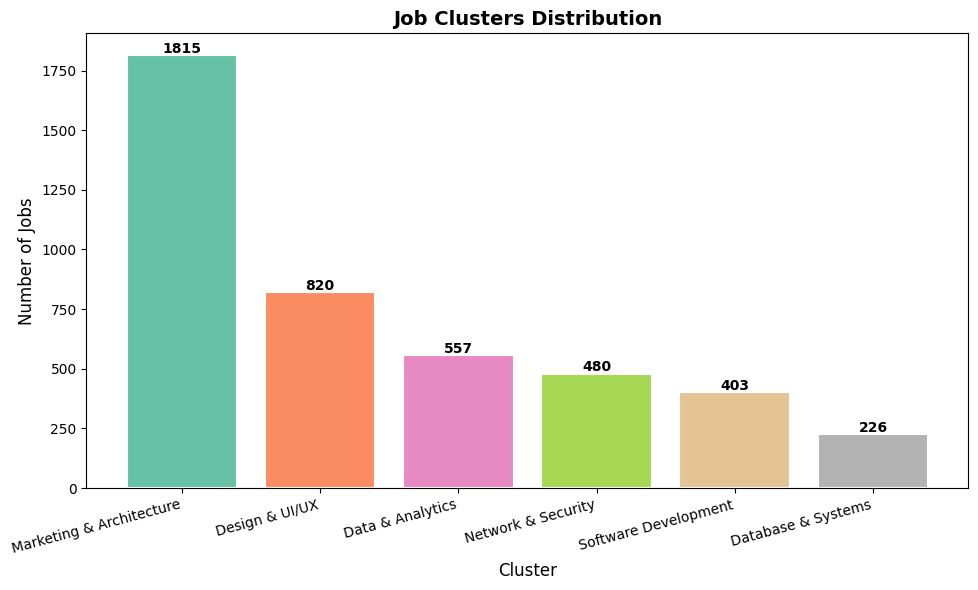


✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/clusters.png


In [5]:
# ── NAME THE CLUSTERS ────────────────────────
# We give meaningful names to each cluster
# Based on what K-Means discovered

cluster_names = {
    0: 'Design & UI/UX',
    1: 'Software Development',
    2: 'Marketing & Architecture',
    3: 'Data & Analytics',
    4: 'Network & Security',
    5: 'Database & Systems'
}

# Add cluster name column to dataframe
df['cluster_name'] = df['cluster'].map(cluster_names)

print("✅ Clusters named!")
print(f"\n📋 Jobs per cluster:")
print("=" * 40)
for cluster_id, name in cluster_names.items():
    count = len(df[df['cluster'] == cluster_id])
    pct   = round(count / len(df) * 100, 1)
    print(f"   {name:<30} : {count} jobs ({pct}%)")

# ── VISUALIZE CLUSTERS ───────────────────────
plt.figure(figsize=(10, 6))

cluster_counts = df['cluster_name'].value_counts()

colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_counts)))

bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels on bars
for bar, val in zip(bars, cluster_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        str(val),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Job Clusters Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

chart_path = f'{OUTPUT_PATH}/clusters.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to: {chart_path}")

In [6]:
# ── TOPIC MODELING (LDA) ─────────────────────

print("⚙️ Training LDA Topic Model...")

# Number of topics to find
N_TOPICS = 6

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,  # Find 6 topics
    random_state=42,
    max_iter=10             # Number of training iterations
)

# Train LDA on TF-IDF matrix
lda.fit(tfidf_matrix)

print(f"✅ LDA Topic Modeling complete!")
print(f"\n📋 DISCOVERED TOPICS:")
print("=" * 50)

feature_names = tfidf.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    # Get top 8 words for this topic
    top_words_idx = topic.argsort()[::-1][:8]
    top_words     = [feature_names[i] for i in top_words_idx]
    
    print(f"\nTopic {topic_idx + 1}:")
    print(f"   Words : {', '.join(top_words)}")

⚙️ Training LDA Topic Model...
✅ LDA Topic Modeling complete!

📋 DISCOVERED TOPICS:

Topic 1:
   Words : engineer, design, system, safety, project, social, develop, control

Topic 2:
   Words : data, business, decision, insight, market, financial, analyze, provide

Topic 3:
   Words : application, design, functional, landscape, user, server, end, developer

Topic 4:
   Words : quality, user, designer, visually, interface, product, layout, visually appealing

Topic 5:
   Words : network, security, system, database, manage, maintain, organization, computer

Topic 6:
   Words : user, performance, interaction, create, specialize, test, enhance, testing


✅ Topics named!

📋 Jobs per topic:
   Engineering & Systems          : 689 jobs (16.0%)
   Data & Business Analytics      : 623 jobs (14.5%)
   Application Development        : 624 jobs (14.5%)
   UI/UX Design                   : 1007 jobs (23.4%)
   Network & Security             : 877 jobs (20.4%)
   Testing & Performance          : 481 jobs (11.2%)


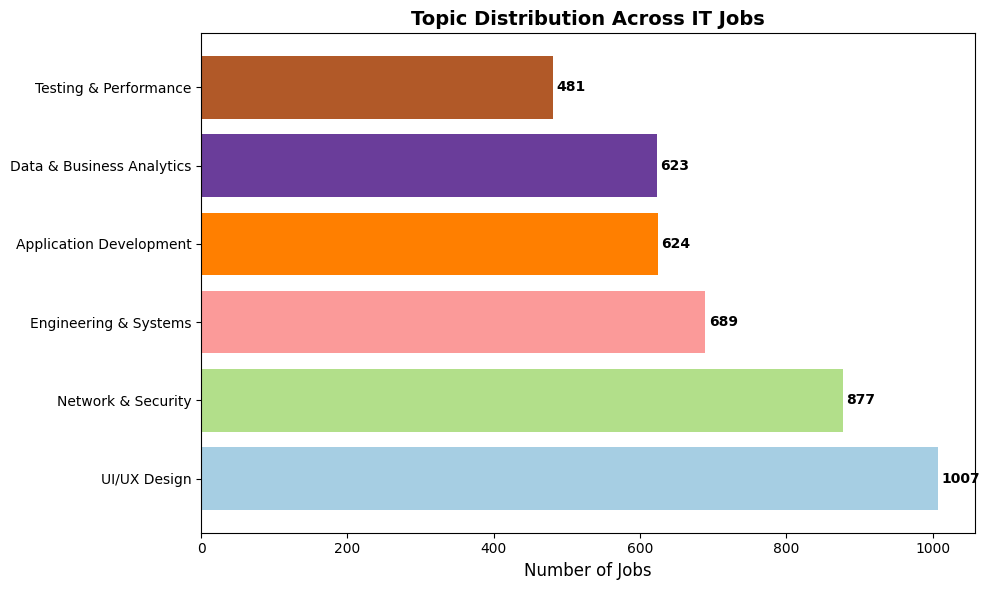


✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/topics.png


In [7]:
# ── NAME THE TOPICS ──────────────────────────

topic_names = {
    0: 'Engineering & Systems',
    1: 'Data & Business Analytics',
    2: 'Application Development',
    3: 'UI/UX Design',
    4: 'Network & Security',
    5: 'Testing & Performance'
}

# Assign dominant topic to each job
topic_assignments = lda.transform(tfidf_matrix)
df['dominant_topic']      = topic_assignments.argmax(axis=1)
df['dominant_topic_name'] = df['dominant_topic'].map(topic_names)

print("✅ Topics named!")
print(f"\n📋 Jobs per topic:")
print("=" * 45)
for topic_id, name in topic_names.items():
    count = len(df[df['dominant_topic'] == topic_id])
    pct   = round(count / len(df) * 100, 1)
    print(f"   {name:<30} : {count} jobs ({pct}%)")

# ── VISUALIZE TOPICS ─────────────────────────
plt.figure(figsize=(10, 6))

topic_counts = df['dominant_topic_name'].value_counts()
colors       = plt.cm.Paired(np.linspace(0, 1, len(topic_counts)))

bars = plt.barh(
    topic_counts.index,
    topic_counts.values,
    color=colors
)

for bar, val in zip(bars, topic_counts.values):
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        str(val),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Topic Distribution Across IT Jobs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.tight_layout()

chart_path = f'{OUTPUT_PATH}/topics.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to: {chart_path}")

In [8]:
# ── SAVE FINAL RESULTS ───────────────────────

save_path = f'{PROCESSED_DATA_PATH}/model_results.csv'

# Select columns to save
df_save = df[[
    'title',
    'description',
    'skills',
    'salary',
    'experience',
    'location',
    'country',
    'work_type',
    'company',
    'date_posted',
    'all_skills_str',
    'skill_count',
    'cluster',
    'cluster_name',
    'dominant_topic',
    'dominant_topic_name'
]]

df_save.to_csv(save_path, index=False)

print(f"✅ Model results saved!")
print(f"📁 Location         : {save_path}")
print(f"📊 Rows             : {len(df_save)}")
print(f"📊 Columns          : {len(df_save.columns)}")
print(f"\n📊 SUMMARY OF NOTEBOOK 4:")
print(f"   TF-IDF features   : 100 important words")
print(f"   K-Means clusters  : 6 job categories")
print(f"   LDA topics        : 6 hidden themes")
print(f"\n   Clusters found:")
for cluster_id, name in cluster_names.items():
    count = len(df[df['cluster'] == cluster_id])
    print(f"   → {name:<30} : {count} jobs")
print(f"\n   Topics found:")
for topic_id, name in topic_names.items():
    count = len(df[df['dominant_topic'] == topic_id])
    print(f"   → {name:<30} : {count} jobs")
print(f"\n🎉 Notebook 4 Complete!")
print(f"👉 Next step → Notebook 5: Insights & Evaluation")

✅ Model results saved!
📁 Location         : D:/Sinali/projects/job_market_intelligence_platform/data/processed/model_results.csv
📊 Rows             : 4301
📊 Columns          : 16

📊 SUMMARY OF NOTEBOOK 4:
   TF-IDF features   : 100 important words
   K-Means clusters  : 6 job categories
   LDA topics        : 6 hidden themes

   Clusters found:
   → Design & UI/UX                 : 820 jobs
   → Software Development           : 403 jobs
   → Marketing & Architecture       : 1815 jobs
   → Data & Analytics               : 557 jobs
   → Network & Security             : 480 jobs
   → Database & Systems             : 226 jobs

   Topics found:
   → Engineering & Systems          : 689 jobs
   → Data & Business Analytics      : 623 jobs
   → Application Development        : 624 jobs
   → UI/UX Design                   : 1007 jobs
   → Network & Security             : 877 jobs
   → Testing & Performance          : 481 jobs

🎉 Notebook 4 Complete!
👉 Next step → Notebook 5: Insights & Evaluati